In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

Random_state = 55

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [6]:
cat_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

df = pd.get_dummies(data = df,
                      prefix = cat_columns,
                      columns = cat_columns)

In [9]:
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,False,True,False,...,False,True,False,True,False,True,False,False,True,False
914,68,144,193,1,141,3.4,1,False,True,True,...,False,False,False,True,False,True,False,False,True,False
915,57,130,131,0,115,1.2,1,False,True,True,...,False,False,False,True,False,False,True,False,True,False
916,57,130,236,0,174,0.0,1,True,False,False,...,False,False,True,False,False,True,False,False,True,False


In [10]:
df.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [ ]:
features = [x for x in df.columns if x not in 'HeartDisease']
features

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'Sex_F',
 'Sex_M',
 'ChestPainType_ASY',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_LVH',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_N',
 'ExerciseAngina_Y',
 'ST_Slope_Down',
 'ST_Slope_Flat',
 'ST_Slope_Up']

In [13]:
X_train, X_val, y_train, y_val = train_test_split(df[features], df['HeartDisease'], test_size=0.2, 
                                                  random_state=Random_state)

In [15]:
print(X_train.shape)
print(X_val.shape)

(734, 20)
(184, 20)


In [19]:
min_samples_split_list = [2, 10, 20, 30, 50, 100, 200, 300, 700]
max_depth_list = [1, 2, 3, 4, 8 , 16, 32, 64, None]

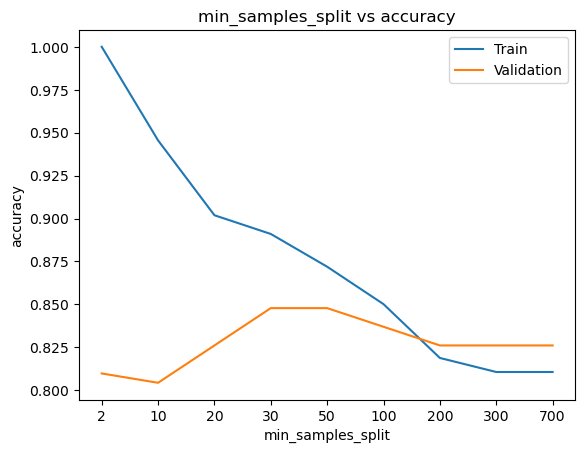

In [26]:
X_train_accuracy = []
X_val_accuracy = []

for min_samples_split in min_samples_split_list:
    model = DecisionTreeClassifier(min_samples_split = min_samples_split, random_state=Random_state).fit(X_train, y_train)

    train_yhat = model.predict(X_train)
    val_yhat = model.predict(X_val)

    train_accuracy = accuracy_score(y_train, train_yhat)
    val_accuracy = accuracy_score(y_val, val_yhat)

    X_train_accuracy.append(train_accuracy)
    X_val_accuracy.append(val_accuracy)

plt.title("min_samples_split vs accuracy")
plt.xlabel("min_samples_split")
plt.ylabel("accuracy")
plt.xticks(ticks=range(len(X_train_accuracy)), labels=min_samples_split_list)
plt.plot(X_train_accuracy)
plt.plot(X_val_accuracy)
plt.legend(["Train", "Validation"])

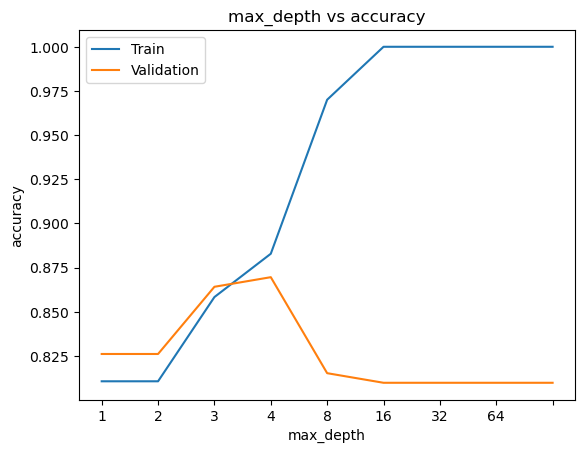

In [27]:
X_train_accuracy = []
X_val_accuracy = []

for max_depth in max_depth_list:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=Random_state).fit(X_train, y_train)
    train_yhat = model.predict(X_train)
    val_yhat = model.predict(X_val)

    train_accuracy = accuracy_score(y_train, train_yhat)
    val_accuracy = accuracy_score(y_val, val_yhat)

    X_train_accuracy.append(train_accuracy)
    X_val_accuracy.append(val_accuracy)

plt.title("max_depth vs accuracy")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.xticks(ticks=range(len(X_train_accuracy)), labels=max_depth_list)
plt.plot(X_train_accuracy)
plt.plot(X_val_accuracy)
plt.legend(["Train", "Validation"])

In [28]:
model = DecisionTreeClassifier(max_depth=4, min_samples_split=30, random_state=Random_state).fit(X_train, y_train)
train_yhat = model.predict(X_train)
val_yhat = model.predict(X_val)

train_accuracy = accuracy_score(y_train, train_yhat)
val_accuracy = accuracy_score(y_val, val_yhat)

print(f"Train_accuracy: {train_accuracy:.2f}")
print(f"Validation accuracy: {val_accuracy:.2f}")


Train_accuracy: 0.88
Validation accuracy: 0.87


RandomForestClassifier

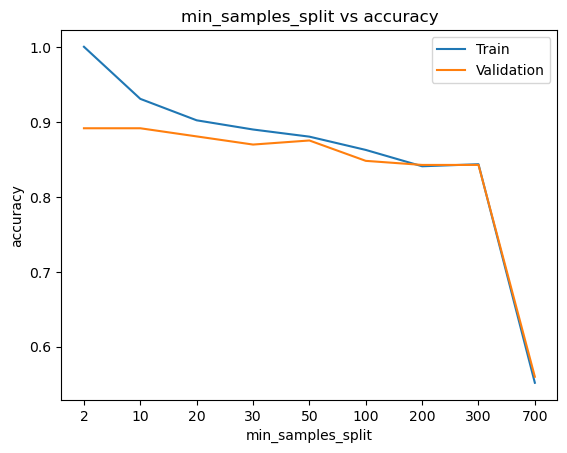

In [29]:
X_train_accuracy = []
X_val_accuracy = []

for min_samples_split in min_samples_split_list:
    model = RandomForestClassifier(min_samples_split = min_samples_split, random_state=Random_state).fit(X_train, y_train)

    train_yhat = model.predict(X_train)
    val_yhat = model.predict(X_val)

    train_accuracy = accuracy_score(y_train, train_yhat)
    val_accuracy = accuracy_score(y_val, val_yhat)

    X_train_accuracy.append(train_accuracy)
    X_val_accuracy.append(val_accuracy)

plt.title("min_samples_split vs accuracy")
plt.xlabel("min_samples_split")
plt.ylabel("accuracy")
plt.xticks(ticks=range(len(X_train_accuracy)), labels=min_samples_split_list)
plt.plot(X_train_accuracy)
plt.plot(X_val_accuracy)
plt.legend(["Train", "Validation"])

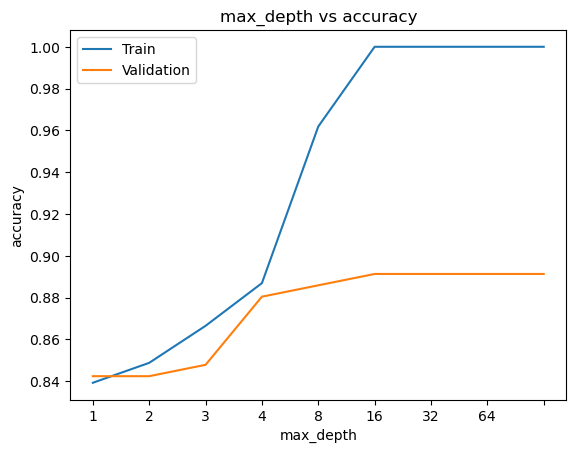

In [30]:
X_train_accuracy = []
X_val_accuracy = []

for max_depth in max_depth_list:
    model = RandomForestClassifier(max_depth=max_depth, random_state=Random_state).fit(X_train, y_train)
    train_yhat = model.predict(X_train)
    val_yhat = model.predict(X_val)

    train_accuracy = accuracy_score(y_train, train_yhat)
    val_accuracy = accuracy_score(y_val, val_yhat)

    X_train_accuracy.append(train_accuracy)
    X_val_accuracy.append(val_accuracy)

plt.title("max_depth vs accuracy")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.xticks(ticks=range(len(X_train_accuracy)), labels=max_depth_list)
plt.plot(X_train_accuracy)
plt.plot(X_val_accuracy)
plt.legend(["Train", "Validation"])

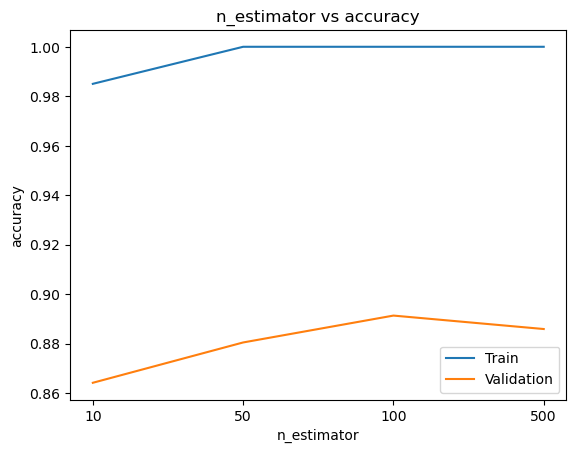

In [32]:
n_estimators_list = [10, 50, 100, 500]
X_train_accuracy = []
X_val_accuracy = []

for n_estimator in n_estimators_list:
    model = RandomForestClassifier(n_estimators=n_estimator, random_state=Random_state).fit(X_train, y_train)
    train_yhat = model.predict(X_train)
    val_yhat = model.predict(X_val)

    train_accuracy = accuracy_score(y_train, train_yhat)
    val_accuracy = accuracy_score(y_val, val_yhat)

    X_train_accuracy.append(train_accuracy)
    X_val_accuracy.append(val_accuracy)

plt.title("n_estimator vs accuracy")
plt.xlabel("n_estimator")
plt.ylabel("accuracy")
plt.xticks(ticks=range(len(X_train_accuracy)), labels= n_estimators_list)
plt.plot(X_train_accuracy)
plt.plot(X_val_accuracy)
plt.legend(["Train", "Validation"])

In [34]:
model = RandomForestClassifier(max_depth=4, min_samples_split=30, n_estimators=100, random_state=Random_state).fit(X_train, y_train)
train_yhat = model.predict(X_train)
val_yhat = model.predict(X_val)

train_accuracy = accuracy_score(y_train, train_yhat)
val_accuracy = accuracy_score(y_val, val_yhat)

print(f"Train_accuracy: {train_accuracy:.2f}")
print(f"Validation accuracy: {val_accuracy:.2f}")

Train_accuracy: 0.88
Validation accuracy: 0.88


XGBoost